# Decision Tree

### Pros
- Interpretability
- Non-linear relationships
- No feature scaling required
- Handles both numerical and categorical data
- Robust to outliers

### Cons
- Overfitting
- High variance
- Instability
- Bias towards features with many levels
- Difficulty in capturing linear relationships

In [1]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, 
    recall_score, precision_score, roc_auc_score
)
from sklearn.tree import plot_tree
from sklearn.feature_selection import RFE

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.over_sampling import ADASYN

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import mlflow
from mlflow.tracking import MlflowClient
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / "requirements.txt").exists():
            return candidate
    return start

project_root = _find_project_root(Path.cwd().resolve())
mlflow_tracking_dir = project_root / "mlruns"
mlflow_tracking_dir.mkdir(parents=True, exist_ok=True)
(mlflow_tracking_dir / ".trash").mkdir(exist_ok=True)
mlflow.set_tracking_uri(mlflow_tracking_dir.as_uri())

experiment_name = "diabetes-models"
client = MlflowClient()
exp = client.get_experiment_by_name(experiment_name)
if exp is None:
    experiment_id = client.create_experiment(experiment_name)
else:
    experiment_id = exp.experiment_id
mlflow.set_experiment(experiment_name)

c:\Users\user\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///C:/Users/user/Desktop/Kolia%20Stuff/SP26/Data%20Science/Project/Data-Science-Project/mlruns/122369565340064861', creation_time=1777931496134, experiment_id='122369565340064861', last_update_time=1777931496134, lifecycle_stage='active', name='diabetes-models', tags={}, trace_location=None, workspace='default'>

## Using Correlation as Feature Selection

<Axes: >

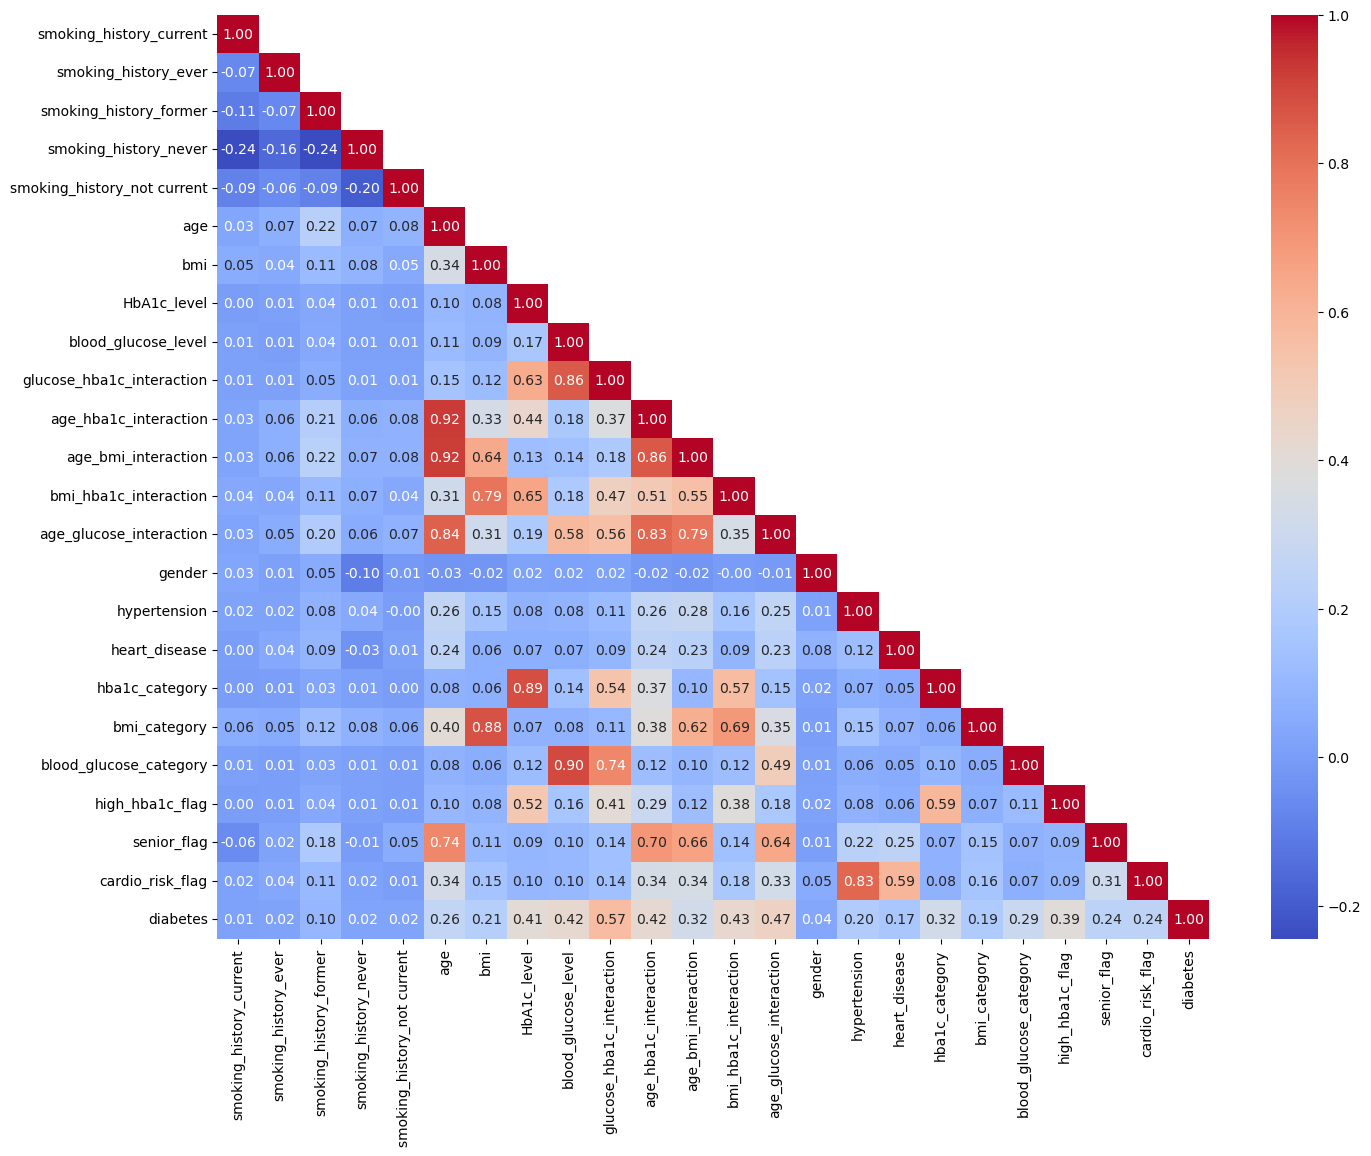

In [3]:
train_preprocessed_df = pd.read_csv("../../data/preprocessed/train_preprocessed.csv") 
validation_preprocessed_df = pd.read_csv("../../data/preprocessed/validation_preprocessed.csv") 

corr_matrix = train_preprocessed_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt=".2f")

### Feature selection Using Correlation

when two features have high correlation remove the one with lower correlation with target

- remove age vs keeping (age_hba1c_interaction , age_bmi_interaction and age_glucose_interaction )
- remove blood_glucose_level vs keeping (glucose_hba1c_interaction)
- remove age_bmi_interaction vs keeping (age_hba1c_interaction) 
- remove age_hba1c_interaction vs keeping ( age_glucose_interaction )
- remove hypertension vs keeping (cardio_flag_risk)
- remove bmi_category vs keeping (bmi)
- remove hba1c_category vs keeping (HbA1C_level)
- remove blood_glucose_category vs keeping (blood_glucose_level)

In [4]:
corr_matrix = corr_matrix.abs()  # abs() catches negative correlations too

upper_triangle = corr_matrix.where(mask.astype(bool))

to_drop = [
    "age",
    "blood_glucose_level",
    "age_bmi_interaction",
    "age_hba1c_interaction",
    "hypertension",
    "bmi_category",
    "hba1c_category",
    "blood_glucose_category"
]

print(f"Features to drop: {to_drop}")

cleared = train_preprocessed_df.drop(columns=to_drop)
print(f"Remaining features: {cleared.columns.tolist()}")

Features to drop: ['age', 'blood_glucose_level', 'age_bmi_interaction', 'age_hba1c_interaction', 'hypertension', 'bmi_category', 'hba1c_category', 'blood_glucose_category']
Remaining features: ['smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'bmi', 'HbA1c_level', 'glucose_hba1c_interaction', 'bmi_hba1c_interaction', 'age_glucose_interaction', 'gender', 'heart_disease', 'high_hba1c_flag', 'senior_flag', 'cardio_risk_flag', 'diabetes']


In [5]:
y_train = cleared['diabetes'].copy()
X_train = cleared.drop('diabetes', axis=1)


y_test = validation_preprocessed_df['diabetes'].copy()
X_test = validation_preprocessed_df.drop('diabetes', axis=1)

# Align test to train columns exactly
X_test = X_test[X_train.columns]

In [6]:
def decision_tree_training(X_train, y_train, X_test, y_test):
    # train
    dt_model = DecisionTreeClassifier(
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    )
    
    dt_model.fit(X_train, y_train)
    
    # predict
    
    y_pred = dt_model.predict(X_test)
    # [0.8 no diabetes , 0.2 diabetes]
    y_prob = dt_model.predict_proba(X_test)[:, 1]
    
    # metrics
    accuracy  = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)      # business metric — catches diabetics
    precision = precision_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)

    print(classification_report(y_test, y_pred))
    

### Trying model

- precision — of everyone we predicted as diabetic, how many actually were?
- recall — of all actual diabetics, how many did we correctly catch? (More Focus)
- f1-score — balance between precision and recall
- accuracy — overall correctness across all samples (not the metric-  Misleading with imbalanced data!)

In [7]:
# normal dataset 
print("====== Normal DataSet ======\n\n")
decision_tree_training(X_train, y_train, X_test, y_test)

====== Normal DataSet ======




              precision    recall  f1-score   support

           0       0.98      0.91      0.95     13115
           1       0.49      0.85      0.62      1272

    accuracy                           0.91     14387
   macro avg       0.74      0.88      0.78     14387
weighted avg       0.94      0.91      0.92     14387



- Recall : Out of every 100 actual diabetic patients
your model correctly identified 85 of them
and missed 15 (Good)

- Precision = 0.49 → only 49% of predicted diabetics actually are (bad)

- F1 = 0.62 → poor balance between precision and recall 

→ Casts a wide net
→ Catches more diabetics (high recall)
→ But too many false alarms (low precision)

gave poor prediction

In [8]:
# trying with smote
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("====== SMOTE DataSet ======\n\n")
decision_tree_training(X_train_res, y_train_res, X_test, y_test)

====== SMOTE DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.97      0.97     13115
           1       0.70      0.76      0.73      1272

    accuracy                           0.95     14387
   macro avg       0.84      0.86      0.85     14387
weighted avg       0.95      0.95      0.95     14387



- Recall : Out of every 0.76 actual diabetic patients
your model correctly identified 76 of them
and missed 24 (less good)

- Precision = 0.70 → only 70% of predicted diabetics actually are (bad)

- F1 = 0.73 →  give better balance between precision and  Recall

- → More conservative
- → Misses more diabetics (lower recall)
- → But more accurate when it does predict diabetic (higher precision)
- → Better overall balance (higher F1)

In [9]:
# trying with smote tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_s_tomek, y_train_s_tomek = smote_tomek.fit_resample(X_train, y_train)
print("====== SMOTE Tomek DataSet ======\n\n")
decision_tree_training(X_train_s_tomek, y_train_s_tomek, X_test, y_test)

====== SMOTE Tomek DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.96      0.97     13115
           1       0.68      0.76      0.72      1272

    accuracy                           0.95     14387
   macro avg       0.83      0.86      0.84     14387
weighted avg       0.95      0.95      0.95     14387



→ Cleaner boundaries helped precision significantly
→ Slight recall drop = 115 more missed diabetics
→ Best overall balance

In [10]:
# trying with smote ENN
smote_enn = SMOTEENN(random_state=42)
X_train_s_enn, y_train_s_enn = smote_enn.fit_resample(X_train, y_train)
print("====== SMOTE ENN DataSet ======\n\n")
decision_tree_training(X_train_s_enn, y_train_s_enn, X_test, y_test)

====== SMOTE ENN DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.93      0.96     13115
           1       0.53      0.85      0.66      1272

    accuracy                           0.92     14387
   macro avg       0.76      0.89      0.81     14387
weighted avg       0.94      0.92      0.93     14387



→ Aggressive cleaning maintained recall
→ But precision barely improved
→ Least effective of the three

In [11]:
# trying with ADASYN
adasyn = ADASYN(random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)
print("====== ADAYSYN DataSet ======\n\n")
decision_tree_training(X_train_ada, y_train_ada, X_test, y_test)

====== ADAYSYN DataSet ======


              precision    recall  f1-score   support

           0       0.98      0.96      0.97     13115
           1       0.67      0.77      0.72      1272

    accuracy                           0.95     14387
   macro avg       0.82      0.87      0.84     14387
weighted avg       0.95      0.95      0.95     14387



ADASYN is A good compormise between more false alarms and more missed diabettes

In [12]:
def do_all(X_train, y_train, X_test, y_test):
    # normal dataset 
    print("====== Normal DataSet ======\n\n")
    decision_tree_training(X_train, y_train, X_test, y_test)
    
    # trying with smote
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("====== SMOTE DataSet ======\n\n")
    decision_tree_training(X_train_res, y_train_res, X_test, y_test)
    
    # trying with smote tomek
    smote_tomek = SMOTETomek(random_state=42)
    X_train_s_tomek, y_train_s_tomek = smote_tomek.fit_resample(X_train, y_train)
    print("====== SMOTE Tomek DataSet ======\n\n")
    decision_tree_training(X_train_s_tomek, y_train_s_tomek, X_test, y_test)
    
    
    # trying with smote ENN
    smote_enn = SMOTEENN(random_state=42)
    X_train_s_enn, y_train_s_enn = smote_enn.fit_resample(X_train, y_train)
    print("====== SMOTE ENN DataSet ======\n\n")
    decision_tree_training(X_train_s_enn, y_train_s_enn, X_test, y_test)
    
    # trying with ADASYN
    adasyn = ADASYN(random_state=42)
    X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)
    print("====== ADAYSYN DataSet ======\n\n")
    decision_tree_training(X_train_ada, y_train_ada, X_test, y_test)

In [13]:
def dt_with_rfe(X_train, y_train, X_test, y_test):
    dt_base = DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight='balanced'
    )
    
    rfe = RFE(
        estimator=dt_base,
        n_features_to_select=8,  # start with 10, we will tune this
        step=1                     # remove 1 feature at a time
    )

    rfe.fit(X_train, y_train)
    
    feature_ranking = pd.DataFrame({
        'feature' : X_train.columns,
        'selected': rfe.support_,    # True/False
        'ranking' : rfe.ranking_     # 1 = selected, higher = removed earlier
    }).sort_values('ranking')

    print("Selected features:")
    print(feature_ranking[feature_ranking['selected'] == True])

    print("\nRemoved features:")
    print(feature_ranking[feature_ranking['selected'] == False])
    
    X_train_rfe = rfe.transform(X_train)
    X_test_rfe  = rfe.transform(X_test)

    do_all(X_train_rfe, y_train, X_test_rfe, y_test)

In [14]:
y_train = train_preprocessed_df['diabetes'].copy()
X_train = train_preprocessed_df.drop('diabetes', axis=1)


y_test = validation_preprocessed_df['diabetes'].copy()
X_test = validation_preprocessed_df.drop('diabetes', axis=1)

dt_with_rfe(X_train, y_train, X_test, y_test)

Selected features:
                      feature  selected  ranking
7                 HbA1c_level      True        1
10      age_hba1c_interaction      True        1
9   glucose_hba1c_interaction      True        1
12      bmi_hba1c_interaction      True        1
11        age_bmi_interaction      True        1
8         blood_glucose_level      True        1
20            high_hba1c_flag      True        1
21                senior_flag      True        1

Removed features:
                        feature  selected  ranking
19       blood_glucose_category     False        2
17               hba1c_category     False        3
18                 bmi_category     False        4
22             cardio_risk_flag     False        5
16                heart_disease     False        6
15                 hypertension     False        7
14                       gender     False        8
13      age_glucose_interaction     False        9
5                           age     False       10
6          

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def train_eval_decision_tree(X_train, y_train, X_val, y_val):
    model = DecisionTreeClassifier(
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob),
    }
    return model, metrics

experiments = []

def add_experiment(name, train_dataset, X_tr, y_tr):
    model, metrics = train_eval_decision_tree(X_tr, y_tr, X_test, y_test)
    experiments.append(
        {"name": name, "train_dataset": train_dataset, "model": model, "metrics": metrics}
    )

add_experiment("Decision Tree - normal", "normal", X_train, y_train)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
add_experiment("Decision Tree - SMOTE", "SMOTE", X_train_smote, y_train_smote)

smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train, y_train)
add_experiment("Decision Tree - SMOTE-Tomek", "SMOTE-Tomek", X_train_tomek, y_train_tomek)

smote_enn = SMOTEENN(random_state=42)
X_train_enn, y_train_enn = smote_enn.fit_resample(X_train, y_train)
add_experiment("Decision Tree - SMOTE-ENN", "SMOTE-ENN", X_train_enn, y_train_enn)

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
add_experiment("Decision Tree - ADASYN", "ADASYN", X_train_adasyn, y_train_adasyn)

best_exp = max(experiments, key=lambda item: item["metrics"]["Recall"])
best_dt_model = best_exp["model"]
best_dt_metrics = best_exp["metrics"]

with mlflow.start_run(experiment_id=experiment_id, run_name=best_exp["name"]):
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("selection_metric", "Recall")
    mlflow.log_param("train_dataset", best_exp["train_dataset"])
    mlflow.log_params(best_dt_model.get_params())
    mlflow.log_metrics(
        {
            f"val_{k.lower().replace('-', '_')}": float(v)
            for k, v in best_dt_metrics.items()
        }
    )

    def _log_confusion_matrix(y_true, y_pred, filename, title):
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots()
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(title)
        mlflow.log_figure(fig, filename)
        plt.close(fig)

    y_test_pred = best_dt_model.predict(X_test)
    _log_confusion_matrix(
        y_test,
        y_test_pred,
        "dt_confusion_matrix_test.png",
        "Decision Tree Test Confusion Matrix",
    )
    mlflow.sklearn.log_model(best_dt_model, "model")

2026/05/05 01:56:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 01:56:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
